# Modélisation de l'incertitude sur le débit d'eau au niveau de d'exutoires et points d'interets.

Pour cette étude préalable, je considère que le débit d'eau au niveau d'un exutoire/infrastructure sera la somme de l'ensemble des débits des tronçons se rejoignant à l'exutoire.

$$\varepsilon_k = \sum_i q_{k-1}^i $$

où :
- $\varepsilon_k$ est le débit au niveau de l'exutoire étudié.
- $q_{k-1}^i$ est le débit du tronçon d'eau juste en avant l'exutoire.

Le debit d'un tronçon à son aval est la somme de son débit en amont + un terme représantant une modification de ce dernier le long du trajet.

$$q_k = \varepsilon_{k-1} + \eta_k$$

- $\varepsilon_{k-1}$ est le débit au niveau de l'exutoire en amont du tronçon d'eau.
- $\eta_k$ est le terme additif représantant l'augmentation du débit venant de la pluie, de retenues d'eau, drainages, ou autres phénomènes pouvant influencer le niveau d'eau le long du tronçon d'eau.

Ainsi le bassin versant d'un cours d'eau se reconstitue naturellement comme une succession de jonction de tronçon d'eau.

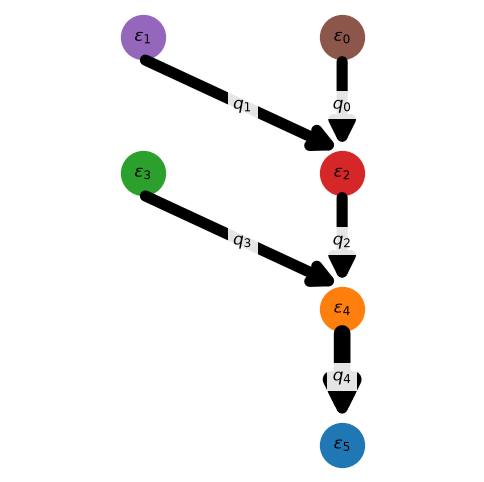

In [1]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 6))

# Positions des noeuds
pos = {
    r"$\varepsilon_5$": (0, -0.5),
    r"$\varepsilon_4$": (0, 0),
    r"$\varepsilon_3$": (-0.3, 0.5),
    r"$\varepsilon_2$": (0, 0.5),
    r"$\varepsilon_1$": (-0.3, 1.0),
    r"$\varepsilon_0$": (0, 1.0)
}

# Arêtes avec noms
edges = [
    (r"$\varepsilon_0$", r"$\varepsilon_2$", r"$q_0$"),
    (r"$\varepsilon_1$", r"$\varepsilon_2$", r"$q_1$"),
    (r"$\varepsilon_2$", r"$\varepsilon_4$", r"$q_2$"),
    (r"$\varepsilon_3$", r"$\varepsilon_4$", r"$q_3$"),
    (r"$\varepsilon_4$", r"$\varepsilon_5$", r"$q_4$"),
    ]

# Dessin des noeuds
for node, (x, y) in pos.items():
    ax.scatter(x, y, s=1000)
    ax.text(x, y, node, ha='center', va='center',
            fontsize=12, fontweight='bold')

# Dessin des flèches et labels
for start, end, label in edges:

    x_start, y_start = pos[start]
    x_end, y_end = pos[end]

    y_start -= 0.08
    y_end += 0.08

    ax.annotate(
        "",
        xy=(x_end, y_end),
        xytext=(x_start, y_start),
        arrowprops=dict(
            arrowstyle="->",
            lw=8,              # épaisseur de la flèche
            mutation_scale=30  # taille de la pointe
        )
    )

    # Position du texte au milieu de la flèche
    x_mid = (x_start + x_end) / 2
    y_mid = (y_start + y_end) / 2

    ax.text(
        x_mid,
        y_mid,
        label,
        fontsize=12,
        ha='center',
        va='center',
        bbox=dict(facecolor='white', edgecolor='none', alpha=0.9)
    )

from matplotlib.patches import FancyArrowPatch

arrow = FancyArrowPatch(
    (x_start, y_start),
    (x_end, y_end),
    arrowstyle='-|>',
    mutation_scale=40,
    linewidth=12
)
ax.add_patch(arrow)

ax.set_xlim(-0.5, 0.2)
ax.set_ylim(-0.6, 1.1)
ax.axis("off")

plt.show()

### Mise en donnée aligné avec les standards SIG

In [2]:
import pandas as pd
import geopandas as gpd

# Création de la dataframe contenant les propriétés des tonçons de cours d'eau
# Ajout d'une propriété NAME pour rendre l'exemple plus clair.
gdf = pd.DataFrame(columns=["HYRIV_ID",
                            "NAME",
                            "NEXT_DOWN",
                            "MAIN_RIV",
                            "LENGTH_KM",
                            "CATCH_SKM",
                            "DIS_AV_CMS",
                            "ENDORHEIC",
                            "ORD_STRA",
                            "geometry"],
                    index=[0, 1, 2, 3, 4])

gdf

,HYRIV_ID,NAME,NEXT_DOWN,MAIN_RIV,LENGTH_KM,CATCH_SKM,DIS_AV_CMS,ENDORHEIC,ORD_STRA,geometry
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Ajout des prorpiétés des tronçons

In [3]:
from numpy import random
for idx in gdf.index:
    # ID du tronçon
    gdf.loc[idx, "HYRIV_ID"] = idx

    gdf.loc[idx, "MAIN_RIV"] = 4

    # Longueur du tronçon (en km) : valeur aléatoire entre 1 et 10
    rand_length = random.uniform(1, 10)
    gdf.loc[idx, "LENGTH_KM"] = rand_length

    # Superficie du bassin versant local (en km²) : valeur aléatoire entre 5 et 10 fois la longueur du tronçon
    gdf.loc[idx, "CATCH_SKM"] = rand_length * random.uniform(5, 10)

    gdf.loc[idx, "ENDORHEIC"] = False

# Noms des tronçons (NAME)
gdf.loc[0, "NAME"] = "Orne_amont"
gdf.loc[1, "NAME"] = "Laize"
gdf.loc[2, "NAME"] = "Orne_millieu"
gdf.loc[3, "NAME"] = "Odon"
gdf.loc[4, "NAME"] = "Orne_aval"

# Tronçon suivant (NEXT_DOWN)
gdf.loc[0, "NEXT_DOWN"] = 2
gdf.loc[1, "NEXT_DOWN"] = 2
gdf.loc[2, "NEXT_DOWN"] = 4
gdf.loc[3, "NEXT_DOWN"] = 4
# Convention pour le tronçon terminal
gdf.loc[4, "NEXT_DOWN"] = 0

# Ordre de Strahler (ORD_STRA)
gdf.loc[0, "ORD_STRA"] = 1
gdf.loc[1, "ORD_STRA"] = 1
gdf.loc[2, "ORD_STRA"] = 2
gdf.loc[3, "ORD_STRA"] = 1
gdf.loc[4, "ORD_STRA"] = 3


gdf


,HYRIV_ID,NAME,NEXT_DOWN,MAIN_RIV,LENGTH_KM,CATCH_SKM,DIS_AV_CMS,ENDORHEIC,ORD_STRA,geometry
0,0,Orne_amont,2,4,9.469011,59.471556,NaN,False,1,NaN
1,1,Laize,2,4,8.152765,50.691661,NaN,False,1,NaN
2,2,Orne_millieu,4,4,2.324831,18.266057,NaN,False,2,NaN
3,3,Odon,4,4,6.836851,43.009033,NaN,False,1,NaN
4,4,Orne_aval,0,4,8.312049,56.447981,NaN,False,3,NaN


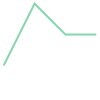

In [4]:
# On ne met pas les géometries dans la dataframe initiale,
# mais on peut les ajouter ensuite pour créer un GeoDataFrame.
from shapely.geometry import LineString

trajet = LineString([
    (1.0, 20.3),
    (1.1, 20.5),
    (1.2, 20.4),
    (1.3, 20.4)
])

trajet

Le paramètres `DIS_AV_CMS`represente le débit moyen en aval de la séction.

Si on considère un valeur fixe pour les exutoires $\varepsilon_1$, $\varepsilon_2$ et $\varepsilon_4$, respectivement, les tronçons $q_1$, $q_2$ et $q_4$ verront leurs débits dépendre du débit au niveau de ces termes sources.

NB: il est aussi possible de considéré ces termes comme nulles, ainsi le débit en aval de ces tronçons ne dépendront uniquement que du gain d'eau au long de ce tronçon.

In [11]:
import numpy as np

# La valeur du débit au niveau d'un exutoire:
# - 0 si l'exutoire en au moins en aval d'un tronçon d'enumerate
# - non null si il est un terme source en amont du réseau (il peut aussi être null en amont)
list_epsilon = [1, 1, 0, 1, 0, 0] 
list_q = [np.nan for _ in range(gdf.shape[0])]

# Pour ce cas simple, on supposera que le terme additif eta dependra de la surface du bassin versant local 
# Par exemple, si il pleut, cette surface peut être utilisée pour estimer la quantité d'eau qui s'écoule dans le tronçon.

# L'idée est de calculer les débits des tronçons d'ordre 1, puis d'ordre 2, puis d'ordre 3, etc...
max_order = max(gdf["ORD_STRA"])
for i_stra in range(1, max_order + 1):

    # On récupère les tronçons d'ordre i_stra
    idx_stra = gdf[gdf["ORD_STRA"] == i_stra].index

    print(f"Calcul des débits pour les tronçons d'ordre {i_stra}:")
    print(idx_stra, "\n")

    for idx in idx_stra:
        # Dabord, on ajoute le terme de l'exutoire en amont, si il existe
        q = list_epsilon[idx]

        # Puis on rajoute un terme additif eta, qui dépend de la surface du bassin versant local
        def eta_func(catch_skm):
            return catch_skm * 0.1
        eta = eta_func(gdf.loc[idx, "CATCH_SKM"])

        q += eta

        # Debit du tronçon
        list_q[idx] = q

        # Il faut maintenant mettre à jour le debit de l'exutoire en aval de ces tronçons
        # On identifie d'abord l'exutoire en aval du tronçon
        next_down_idx = gdf.loc[idx, "NEXT_DOWN"]
        # Puis on ajoute le debit du tronçon au debit de l'exutoire en aval
        # Cas spécial pour le tronçon terminal, qui n'a pas d'exutoire en aval
        if next_down_idx == 0:
            list_epsilon[-1] += q
        else:
            list_epsilon[next_down_idx] += q

Calcul des débits pour les tronçons d'ordre 1:
Index([0, 1, 3], dtype='int64') 

Calcul des débits pour les tronçons d'ordre 2:
Index([2], dtype='int64') 

Calcul des débits pour les tronçons d'ordre 3:
Index([4], dtype='int64') 



In [12]:
list_q

[6.947155634874681,
 6.06916611456266,
 14.842927411506174,
 5.300903280773124,
 25.788628841665187]

In [13]:
list_epsilon

[1, 1, 13.016321749437342, 1, 20.1438306922793, 25.788628841665187]

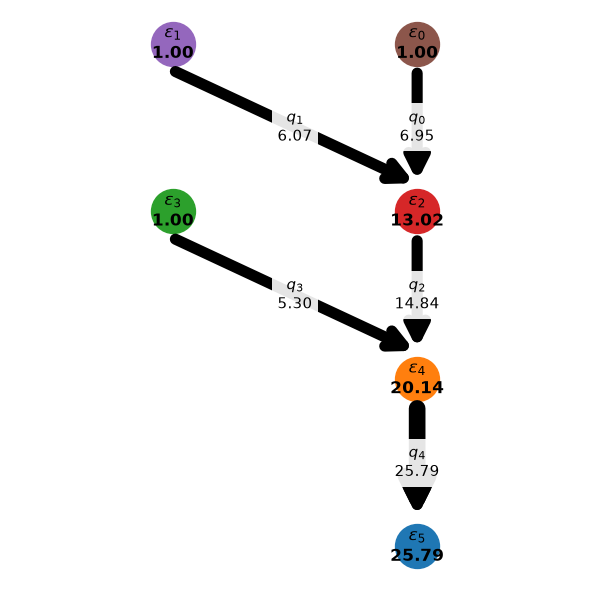

In [14]:
fig, ax = plt.subplots(figsize=(6, 6))

# Positions des noeuds
pos = {
    5: (0, -0.5),
    4: (0, 0),
    3: (-0.3, 0.5),
    2: (0, 0.5),
    1: (-0.3, 1.0),
    0: (0, 1.0)
}

# Arêtes : (départ, arrivée, indice q)
edges = [
    (0, 2, 0),
    (1, 2, 1),
    (2, 4, 2),
    (3, 4, 3),
    (4, 5, 4),
]

# Dessin des noeuds
for idx, (x, y) in pos.items():

    ax.scatter(x, y, s=1000)

    ax.text(
        x,
        y,
        rf"$\varepsilon_{{{idx}}}$" + f"\n{list_epsilon[idx]:.2f}",
        ha="center",
        va="center",
        fontsize=12,
        fontweight="bold",
    )

# Dessin des flèches et labels
for start, end, q_idx in edges:

    x_start, y_start = pos[start]
    x_end, y_end = pos[end]

    y_start -= 0.08
    y_end += 0.08

    ax.annotate(
        "",
        xy=(x_end, y_end),
        xytext=(x_start, y_start),
        arrowprops=dict(
            arrowstyle="->",
            lw=8,
            mutation_scale=30
        )
    )

    x_mid = (x_start + x_end) / 2
    y_mid = (y_start + y_end) / 2

    ax.text(
        x_mid,
        y_mid,
        rf"$q_{{{q_idx}}}$" + f"\n{list_q[q_idx]:.2f}",
        fontsize=11,
        ha="center",
        va="center",
        bbox=dict(
            facecolor="white",
            edgecolor="none",
            alpha=0.9
        )
    )

# Flèche épaisse finale (optionnelle)
x_start, y_start = pos[4]
x_end, y_end = pos[5]

y_start -= 0.08
y_end += 0.08

arrow = FancyArrowPatch(
    (x_start, y_start),
    (x_end, y_end),
    arrowstyle='-|>',
    mutation_scale=40,
    linewidth=12
)
ax.add_patch(arrow)

ax.set_xlim(-0.5, 0.2)
ax.set_ylim(-0.6, 1.1)
ax.axis("off")

plt.tight_layout()
plt.show()